# Mafia Island MPA — Sea Surface Temperature

Climate Indicator 01 | Fact Sheet Development

| | |
|---|---|
| Location | Mafia Island MPA, Tanzania (7.85°S, 39.82°E) |
| Data source | NOAA OISST v2.1 (annual NetCDF files) |
| CRW source | NOAA Coral Reef Watch Virtual Station Tanzania |
| Record | 1985 to 2024 |
| Baseline | 1985 to 2005 |

Workflow:

1. Setup and configuration
2. Load and clip annual NetCDF files to daily time series
3. Compute monthly and annual means plus climatology
4. Marine heatwave detection (Hobday et al. 2016/2018)
5. Figure 1 — Long-term SST trend
6. Figure 2 — Seasonal climatology shift
7. Figure 3 — Marine heatwave analysis
8. Figure 4 — Degree heating weeks (CRW)
9. Figure 5 — SST anomaly heatmap
10. Export headline numbers and visual summary


## 1. Setup and configuration

In [ ]:
# Uncomment and run once if packages are missing
# %pip install numpy pandas scipy xarray netCDF4 matplotlib h5netcdf

In [73]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import xarray as xr
from pathlib import Path
from scipy import stats
from scipy.ndimage import uniform_filter1d

warnings.filterwarnings("ignore")

# Paths
# This notebook lives in: indicators/01_SST/scripts/
# BASE resolves to the indicators/01_SST/ folder
BASE      = Path().resolve().parent
DATA_RAW  = BASE / "data" / "raw"
DATA_PROC = BASE / "data" / "processed"
DATA_OUT  = BASE / "data" / "outputs"
FIG_DIR   = BASE / "figures"

for p in [DATA_PROC, DATA_OUT, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Study area
CENTRE_LAT = -7.85
CENTRE_LON =  39.82
LAT_MIN, LAT_MAX = -8.5, -7.0
LON_MIN, LON_MAX =  39.0,  40.5

# Period parameters
BASELINE_START = 1985
BASELINE_END   = 2005
RECORD_START   = 1985
RECORD_END     = 2024
CLIM_WINDOW    = 15        # ±15 days (Hobday et al. 2016)

BLEACHING_YEARS = [1998, 2010, 2016, 2024]

# Style constants
C_SST    = "#1565C0"
C_TREND  = "#212121"
C_SMOOTH = "#D32F2F"
C_ANNOT  = "#9E9E9E"
C_EARLY  = "#1976D2"
C_RECENT = "#D32F2F"

MHW_COLOURS = {
    "Moderate": "#FFC107",
    "Strong":   "#FF7043",
    "Severe":   "#D32F2F",
    "Extreme":  "#6A1B9A",
}

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Confirm paths
nc_files = sorted(DATA_RAW.glob("sst.day.mean.*.nc"))
print(f"Base folder      : {BASE}")
print(f"Raw folder       : {DATA_RAW}")
print(f"NetCDF files     : {len(nc_files)}")
if nc_files:
    print(f"  First : {nc_files[0].name}")
    print(f"  Last  : {nc_files[-1].name}")
else:
    print("  WARNING: No .nc files found — check your raw folder path")
print("Configuration loaded ✓")


Base folder      : E:\Git_Repositories\CliMPA\indicators\01_SST
Raw folder       : E:\Git_Repositories\CliMPA\indicators\01_SST\data\raw
NetCDF files     : 40
  First : sst.day.mean.1985.nc
  Last  : sst.day.mean.2024.nc
Configuration loaded ✓


## 2. Load and clip annual NetCDF files

Each annual file covers the entire globe at 0.25° resolution. This section clips every file to the Mafia Island MPA bounding box and computes a spatial mean, producing one daily SST value per day for 1985 to 2024.

This cell runs once. Output is saved to data/processed/SST_daily.csv. On subsequent runs it loads directly from that file, skipping the slow NetCDF step.


In [91]:
DAILY_CSV = DATA_PROC / "SST_daily.csv"

if DAILY_CSV.exists():
    DAILY_CSV.unlink()
    print("Deleted existing CSV — reprocessing...")

nc_files = sorted(DATA_RAW.glob("sst.day.mean.*.nc"))
print(f"Found {len(nc_files)} NetCDF files\n")

records = []
for f in nc_files:
    year = f.stem.split(".")[-1]
    print(f"  Processing {f.name} ...", end=" ")

    ds      = xr.open_dataset(f)
    ds_clip = ds.sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX)
    )
    sst_mean = ds_clip["sst"].mean(dim=["lat", "lon"])
    df = sst_mean.to_dataframe(name="sst").reset_index()
    df = df.rename(columns={"time": "date"})[["date", "sst"]]
    df["sst"] = pd.to_numeric(df["sst"], errors="coerce")
    records.append(df)
    ds.close()
    print(f"{len(df)} days | mean = {df['sst'].mean():.2f} °C")

daily = pd.concat(records, ignore_index=True)
daily = daily.dropna(subset=["sst"]).sort_values("date").reset_index(drop=True)
daily["date"] = pd.to_datetime(daily["date"])
daily.to_csv(DAILY_CSV, index=False)

print(f"\nSaved: {DAILY_CSV}")
print(f"Total: {len(daily):,} daily records")
print(f"Range: {daily['date'].min().date()} to {daily['date'].max().date()}")
print(f"SST  : {daily['sst'].min():.2f} to {daily['sst'].max():.2f} °C")


Deleted existing CSV — reprocessing...
Found 41 NetCDF files

  Processing sst.day.mean.1985.nc ... 365 days | mean = 27.21 °C
  Processing sst.day.mean.1986.nc ... 365 days | mean = 27.27 °C
  Processing sst.day.mean.1987.nc ... 365 days | mean = 27.70 °C
  Processing sst.day.mean.1988.nc ... 366 days | mean = 27.85 °C
  Processing sst.day.mean.1989.nc ... 365 days | mean = 27.08 °C
  Processing sst.day.mean.1990.nc ... 365 days | mean = 27.49 °C
  Processing sst.day.mean.1991.nc ... 365 days | mean = 27.31 °C
  Processing sst.day.mean.1992.nc ... 366 days | mean = 27.36 °C
  Processing sst.day.mean.1993.nc ... 365 days | mean = 27.25 °C
  Processing sst.day.mean.1994.nc ... 365 days | mean = 27.35 °C
  Processing sst.day.mean.1995.nc ... 365 days | mean = 27.40 °C
  Processing sst.day.mean.1996.nc ... 366 days | mean = 27.29 °C
  Processing sst.day.mean.1997.nc ... 365 days | mean = 27.35 °C
  Processing sst.day.mean.1998.nc ... 365 days | mean = 27.88 °C
  Processing sst.day.mean.19

## 3. Compute monthly and annual means plus climatology

In [94]:
daily["year"]  = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["doy"]   = daily["date"].dt.day_of_year

monthly = (
    daily.groupby(["year", "month"])["sst"]
    .agg(sst_mean="mean", sst_min="min", sst_max="max")
    .reset_index()
)
monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=15))

annual = daily.groupby("year")["sst"].mean().reset_index(name="sst_mean")

monthly.to_csv(DATA_PROC / "SST_monthly.csv", index=False)
annual.to_csv(DATA_PROC  / "SST_annual.csv",  index=False)

print(f"Monthly means : {len(monthly)} records")
print(f"Annual means  : {len(annual)} records")
print(f"\nAnnual SST summary:")
print(annual.tail(10).to_string(index=False))


Monthly means : 492 records
Annual means  : 41 records

Annual SST summary:
 year  sst_mean
 2016 27.904081
 2017 28.010529
 2018 27.806009
 2019 28.092695
 2020 28.030151
 2021 27.654085
 2022 27.548025
 2023 28.063610
 2024 28.409155
 2025 27.945885


In [95]:
# Daily climatology: clim_mean and P90 (Hobday et al. 2016)
print("Computing daily climatology using ±15-day window over 1985 to 2005 baseline...")

baseline = daily[daily["year"].between(BASELINE_START, BASELINE_END)].copy()
results  = []

for doy in range(1, 367):
    window_doys = set(((d - 1) % 365) + 1
                      for d in range(doy - CLIM_WINDOW, doy + CLIM_WINDOW + 1))
    vals = baseline[baseline["doy"].isin(window_doys)]["sst"]
    results.append({
        "doy":       doy,
        "clim_mean": vals.mean()        if len(vals) >= 10 else np.nan,
        "p90":       vals.quantile(.9)  if len(vals) >= 10 else np.nan,
        "n_obs":     len(vals),
    })

clim = pd.DataFrame(results)
clim.to_csv(DATA_PROC / "SST_climatology.csv", index=False)
print(f"Climatology saved (avg {clim['n_obs'].mean():.0f} obs per calendar day)")


Computing daily climatology using ±15-day window over 1985 to 2005 baseline...
Climatology saved (avg 651 obs per calendar day)


In [97]:
# Monthly anomalies vs 1985 to 2005 baseline
baseline_monthly = (
    monthly[monthly["year"].between(BASELINE_START, BASELINE_END)]
    .groupby("month")["sst_mean"].mean()
    .rename("clim_monthly_mean")
)
anomaly = monthly.copy().join(baseline_monthly, on="month")
anomaly["anomaly"] = anomaly["sst_mean"] - anomaly["clim_monthly_mean"]
anomaly.to_csv(DATA_PROC / "SST_anomaly_monthly.csv", index=False)

print("Monthly anomalies saved")
print(f"\nRecent anomalies (last 12 months):")
print(anomaly.tail(12)[["year", "month", "sst_mean", "anomaly"]].to_string(index=False))


Monthly anomalies saved

Recent anomalies (last 12 months):
 year  month  sst_mean  anomaly
 2025      1 28.993547 0.416922
 2025      2 28.990025 0.235113
 2025      3 29.645357 0.321861
 2025      4 29.284035 0.429302
 2025      5 28.544897 0.559711
 2025      6 27.568047 0.769251
 2025      7 26.234215 0.426420
 2025      8 25.704308 0.397161
 2025      9 26.283773 0.632744
 2025     10 26.898870 0.504639
 2025     11 28.159178 0.544863
 2025     12 29.129663 0.651419


## 4. Marine heatwave detection (Hobday et al. 2016/2018)

A marine heatwave is defined as SST exceeding the 90th percentile for five or more consecutive days. Category is based on multiples of the gap between P90 and the climatological mean.


In [98]:
daily = daily.merge(clim[["doy", "clim_mean", "p90"]], on="doy", how="left")
daily["gap"]       = daily["p90"] - daily["clim_mean"]
daily["intensity"] = np.where(daily["sst"] > daily["p90"],
                               daily["sst"] - daily["p90"], 0.0)
daily["is_above"]  = daily["sst"] > daily["p90"]

def classify(intensity, gap):
    if intensity <= 0 or pd.isna(gap) or gap <= 0: return None
    m = intensity / gap
    if m >= 3: return "Extreme"
    if m >= 2: return "Severe"
    if m >= 1: return "Strong"
    return "Moderate"

daily["category"] = daily.apply(lambda r: classify(r["intensity"], r["gap"]), axis=1)

# Flag confirmed events (5 or more consecutive days)
daily["mhw_event"] = False
streak = []
for idx, row in daily.iterrows():
    if row["is_above"]:
        streak.append(idx)
    else:
        if len(streak) >= 5:
            daily.loc[streak, "mhw_event"] = True
        streak = []
if len(streak) >= 5:
    daily.loc[streak, "mhw_event"] = True

daily.loc[~daily["mhw_event"], ["intensity", "category"]] = [0.0, None]
daily.to_csv(DATA_PROC / "MHW_daily_flags.csv", index=False)

total = daily["mhw_event"].sum()
print(f"MHW days: {total:,} ({total/len(daily)*100:.1f}% of record)")
print()
for cat in ["Moderate", "Strong", "Severe", "Extreme"]:
    n   = (daily["category"] == cat).sum()
    bar = "█" * (n // 10)
    print(f"  {cat:10s}: {n:5d} days  {bar}")


MHW days: 1,845 (12.3% of record)

  Moderate  :  1694 days  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Strong    :   150 days  ███████████████
  Severe    :     1 days  
  Extreme   :     0 days  


In [99]:
# Event-level summary table
events, in_event, ev_rows = [], False, []

for _, row in daily.iterrows():
    if row["mhw_event"]:
        if not in_event:
            in_event, ev_rows = True, []
        ev_rows.append(row)
    else:
        if in_event and len(ev_rows) >= 5:
            df = pd.DataFrame(ev_rows)
            events.append({
                "start":          df["date"].min().date(),
                "end":            df["date"].max().date(),
                "duration_days":  len(df),
                "max_intensity":  round(df["intensity"].max(), 2),
                "mean_intensity": round(df["intensity"].mean(), 2),
                "peak_sst":       round(df["sst"].max(), 2),
                "max_category":   df["category"].mode().iloc[0] if not df["category"].isna().all() else None,
            })
        in_event, ev_rows = False, []

mhw_events = pd.DataFrame(events)
mhw_events.to_csv(DATA_PROC / "MHW_events.csv", index=False)
print(f"{len(mhw_events)} MHW events detected and saved")
print()
print(mhw_events.tail(10).to_string(index=False))


129 MHW events detected and saved

     start        end  duration_days  max_intensity  mean_intensity  peak_sst max_category
2024-06-16 2024-10-17            124           1.00            0.50     27.61     Moderate
2024-10-19 2024-11-30             43           0.56            0.26     29.01     Moderate
2024-12-09 2024-12-29             21           0.74            0.41     29.86     Moderate
2025-01-09 2025-01-13              5           0.12            0.07     29.62     Moderate
2025-04-24 2025-05-04             11           0.13            0.08     29.38     Moderate
2025-05-21 2025-06-15             26           0.32            0.14     28.80     Moderate
2025-06-27 2025-07-01              5           0.19            0.13     27.10     Moderate
2025-08-22 2025-09-14             24           0.33            0.18     26.37     Moderate
2025-11-25 2025-11-30              6           0.29            0.20     29.09     Moderate
2025-12-05 2025-12-18             14           0.67    

## 5. Figure 1 — Long-term SST trend

In [101]:
monthly = pd.read_csv(DATA_PROC / "SST_monthly.csv", parse_dates=["date"]).sort_values("date")
x = np.arange(len(monthly))
y = monthly["sst_mean"].values

slope, intercept, r, p, se = stats.linregress(x.astype(float), y.astype(float))
trend    = slope * x + intercept
rate     = slope * 12 * 10
smoothed = uniform_filter1d(y.astype(float), size=24)

print(f"Warming rate : {rate:+.3f} °C/decade")
print(f"R²           : {r**2:.3f}")
print(f"p-value      : {p:.4f}  ({'SIGNIFICANT' if p < 0.05 else 'not significant'})")


Warming rate : +0.165 °C/decade
R²           : 0.020
p-value      : 0.0018  (SIGNIFICANT)


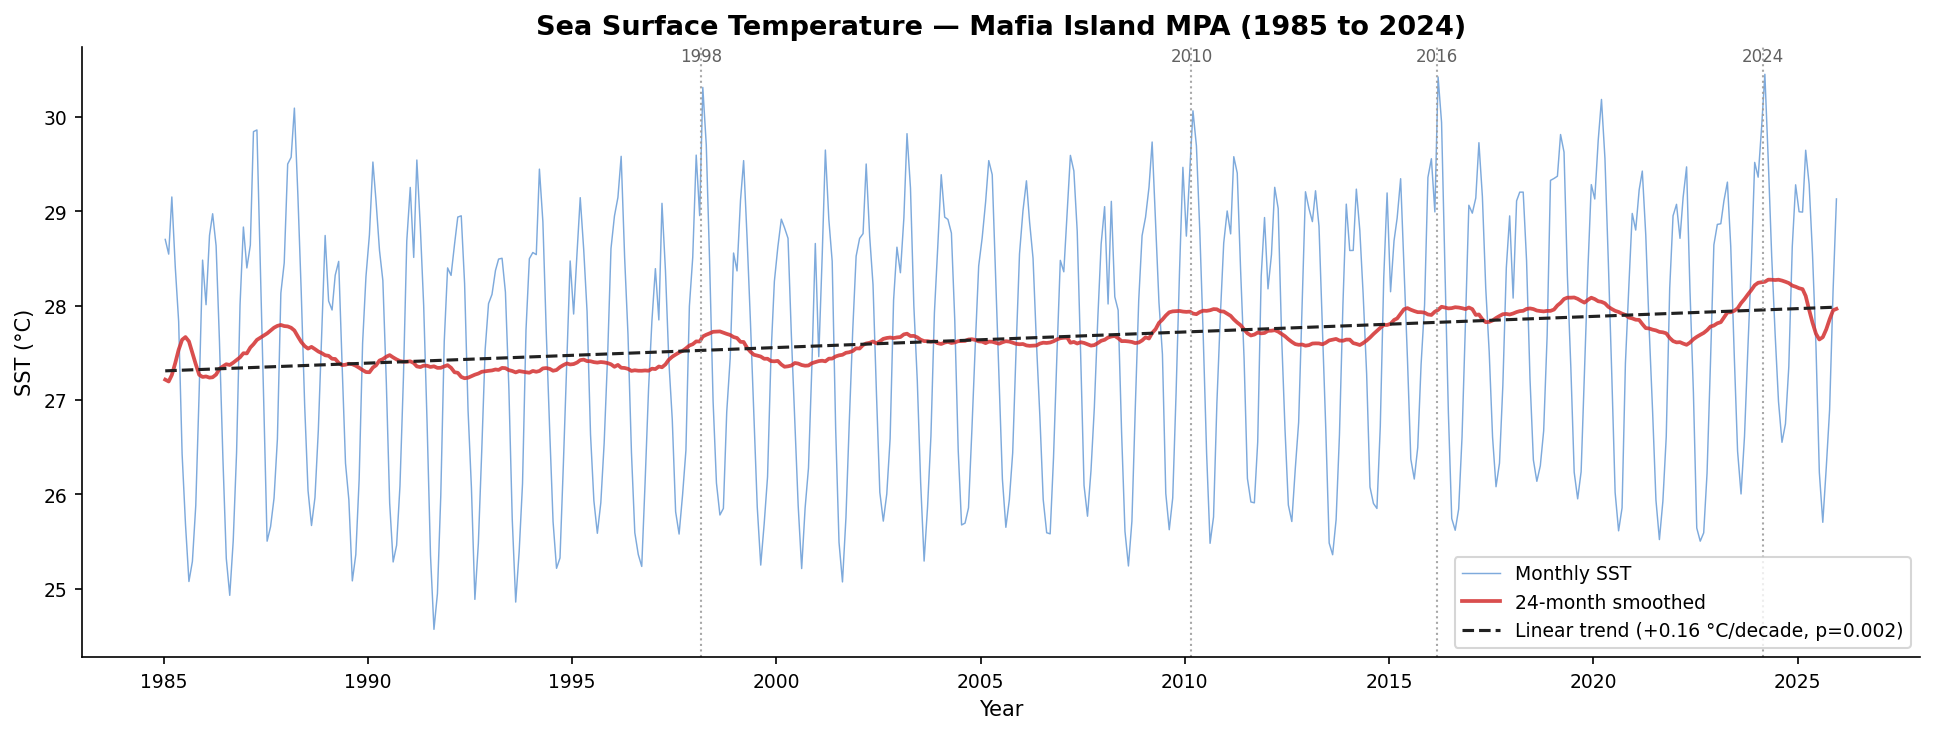

Saved to E:\Git_Repositories\CliMPA\indicators\01_SST\figures\fig1_SST_longterm_trend.png


In [102]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly["date"], y,        color=C_SST,    lw=0.7, alpha=0.55, label="Monthly SST")
ax.plot(monthly["date"], smoothed, color=C_SMOOTH, lw=1.8, alpha=0.85, label="24-month smoothed")
ax.plot(monthly["date"], trend,    color=C_TREND,  lw=1.5, ls="--",
        label=f"Linear trend ({rate:+.2f} °C/decade, p={p:.3f})")

for yr in BLEACHING_YEARS:
    d = pd.Timestamp(f"{yr}-03-01")
    if monthly["date"].min() <= d <= monthly["date"].max():
        ax.axvline(d, color=C_ANNOT, lw=1.0, ls=":", alpha=0.9)
        ax.text(d, y.max() + 0.1, str(yr), fontsize=8,
                ha="center", va="bottom", color="#616161")

ax.set_title("Sea Surface Temperature — Mafia Island MPA (1985 to 2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("SST (°C)")
ax.legend(fontsize=9)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_SST_longterm_trend.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig1_SST_longterm_trend.svg", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG_DIR / 'fig1_SST_longterm_trend.png'}")


## 6. Figure 2 — Seasonal climatology shift

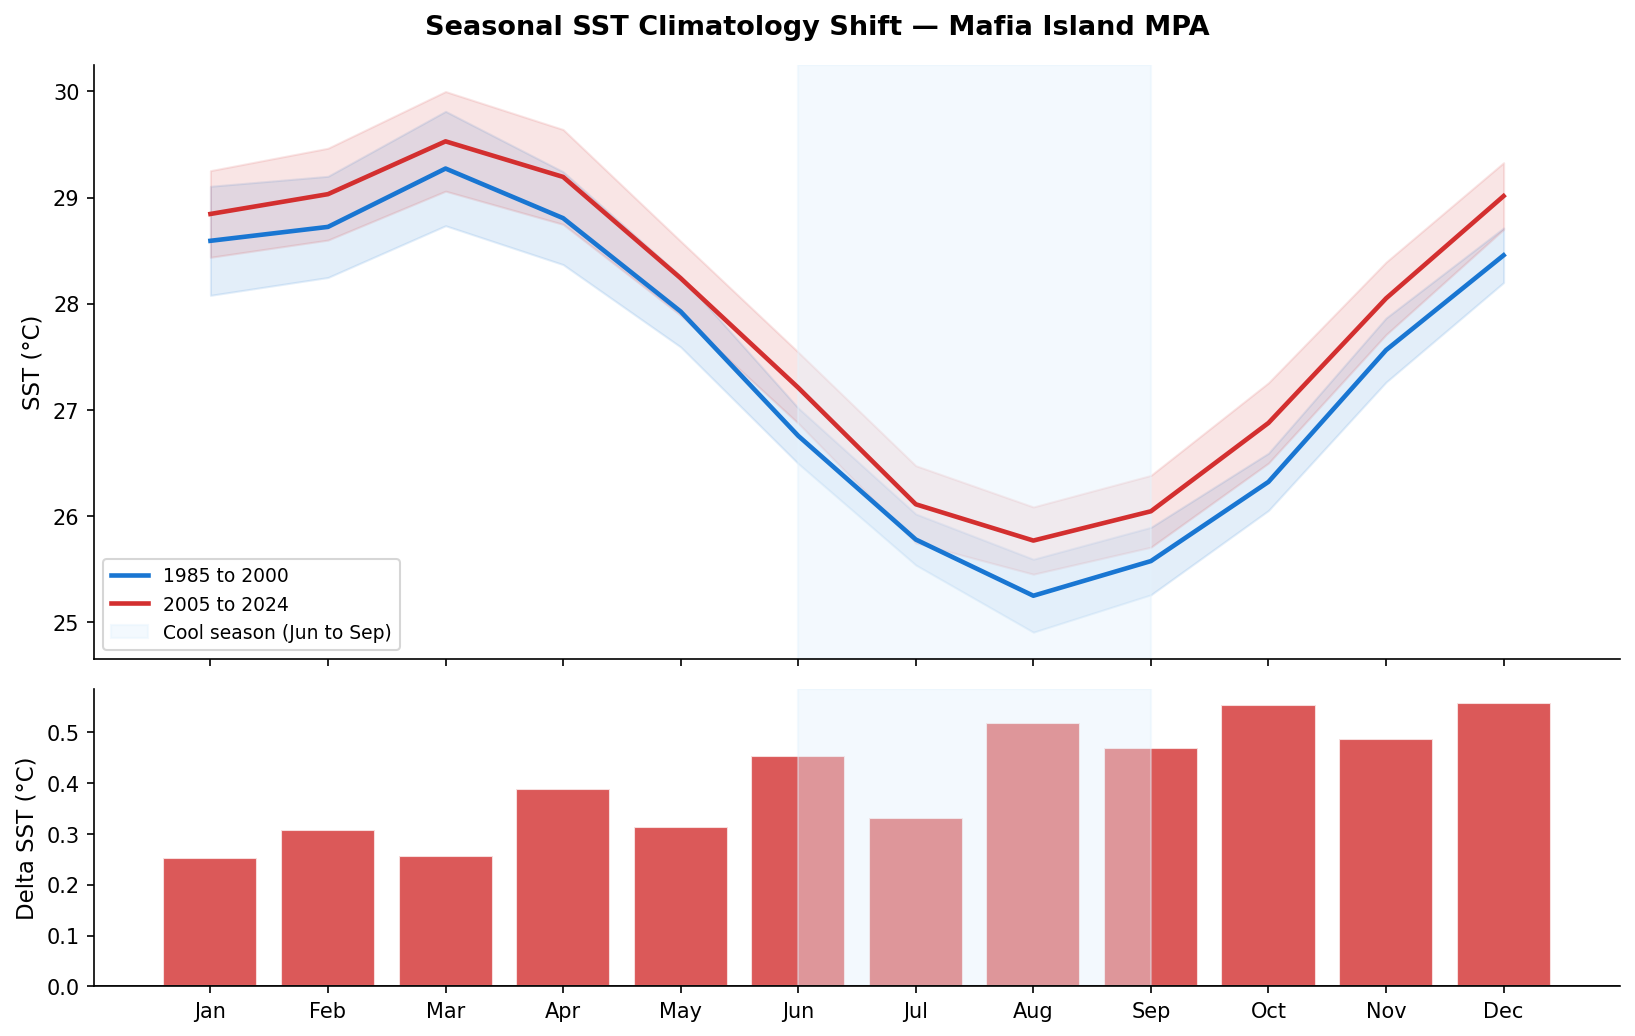

Cool season (Jun to Sep) warming shift: +0.44 °C


In [103]:
monthly = pd.read_csv(DATA_PROC / "SST_monthly.csv")
early  = monthly[monthly["year"].between(1985, 2000)].groupby("month")["sst_mean"].agg(["mean", "std"])
recent = monthly[monthly["year"].between(2005, 2024)].groupby("month")["sst_mean"].agg(["mean", "std"])
diff   = recent["mean"] - early["mean"]
months = range(1, 13)
labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("Seasonal SST Climatology Shift — Mafia Island MPA", fontsize=13, fontweight="bold")

ax1.fill_between(months, early["mean"]  - early["std"],  early["mean"]  + early["std"],  color=C_EARLY,  alpha=0.12)
ax1.fill_between(months, recent["mean"] - recent["std"], recent["mean"] + recent["std"], color=C_RECENT, alpha=0.12)
ax1.plot(months, early["mean"],  color=C_EARLY,  lw=2.2, label="1985 to 2000")
ax1.plot(months, recent["mean"], color=C_RECENT, lw=2.2, label="2005 to 2024")
ax1.axvspan(6, 9, color="#E3F2FD", alpha=0.4, label="Cool season (Jun to Sep)")
ax1.set_ylabel("SST (°C)", fontsize=11)
ax1.legend(fontsize=9)

colours = [C_RECENT if v > 0 else C_EARLY for v in diff]
ax2.bar(months, diff, color=colours, alpha=0.8, edgecolor="white")
ax2.axhline(0, color="#212121", lw=0.8)
ax2.axvspan(6, 9, color="#E3F2FD", alpha=0.4)
ax2.set_ylabel("Delta SST (°C)", fontsize=11)
ax2.set_xticks(list(months))
ax2.set_xticklabels(labels)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_seasonal_climatology.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig2_seasonal_climatology.svg", bbox_inches="tight")
plt.show()

cool_shift = diff.loc[6:9].mean()
print(f"Cool season (Jun to Sep) warming shift: {cool_shift:+.2f} °C")


## 7. Figure 3 — Marine heatwave analysis

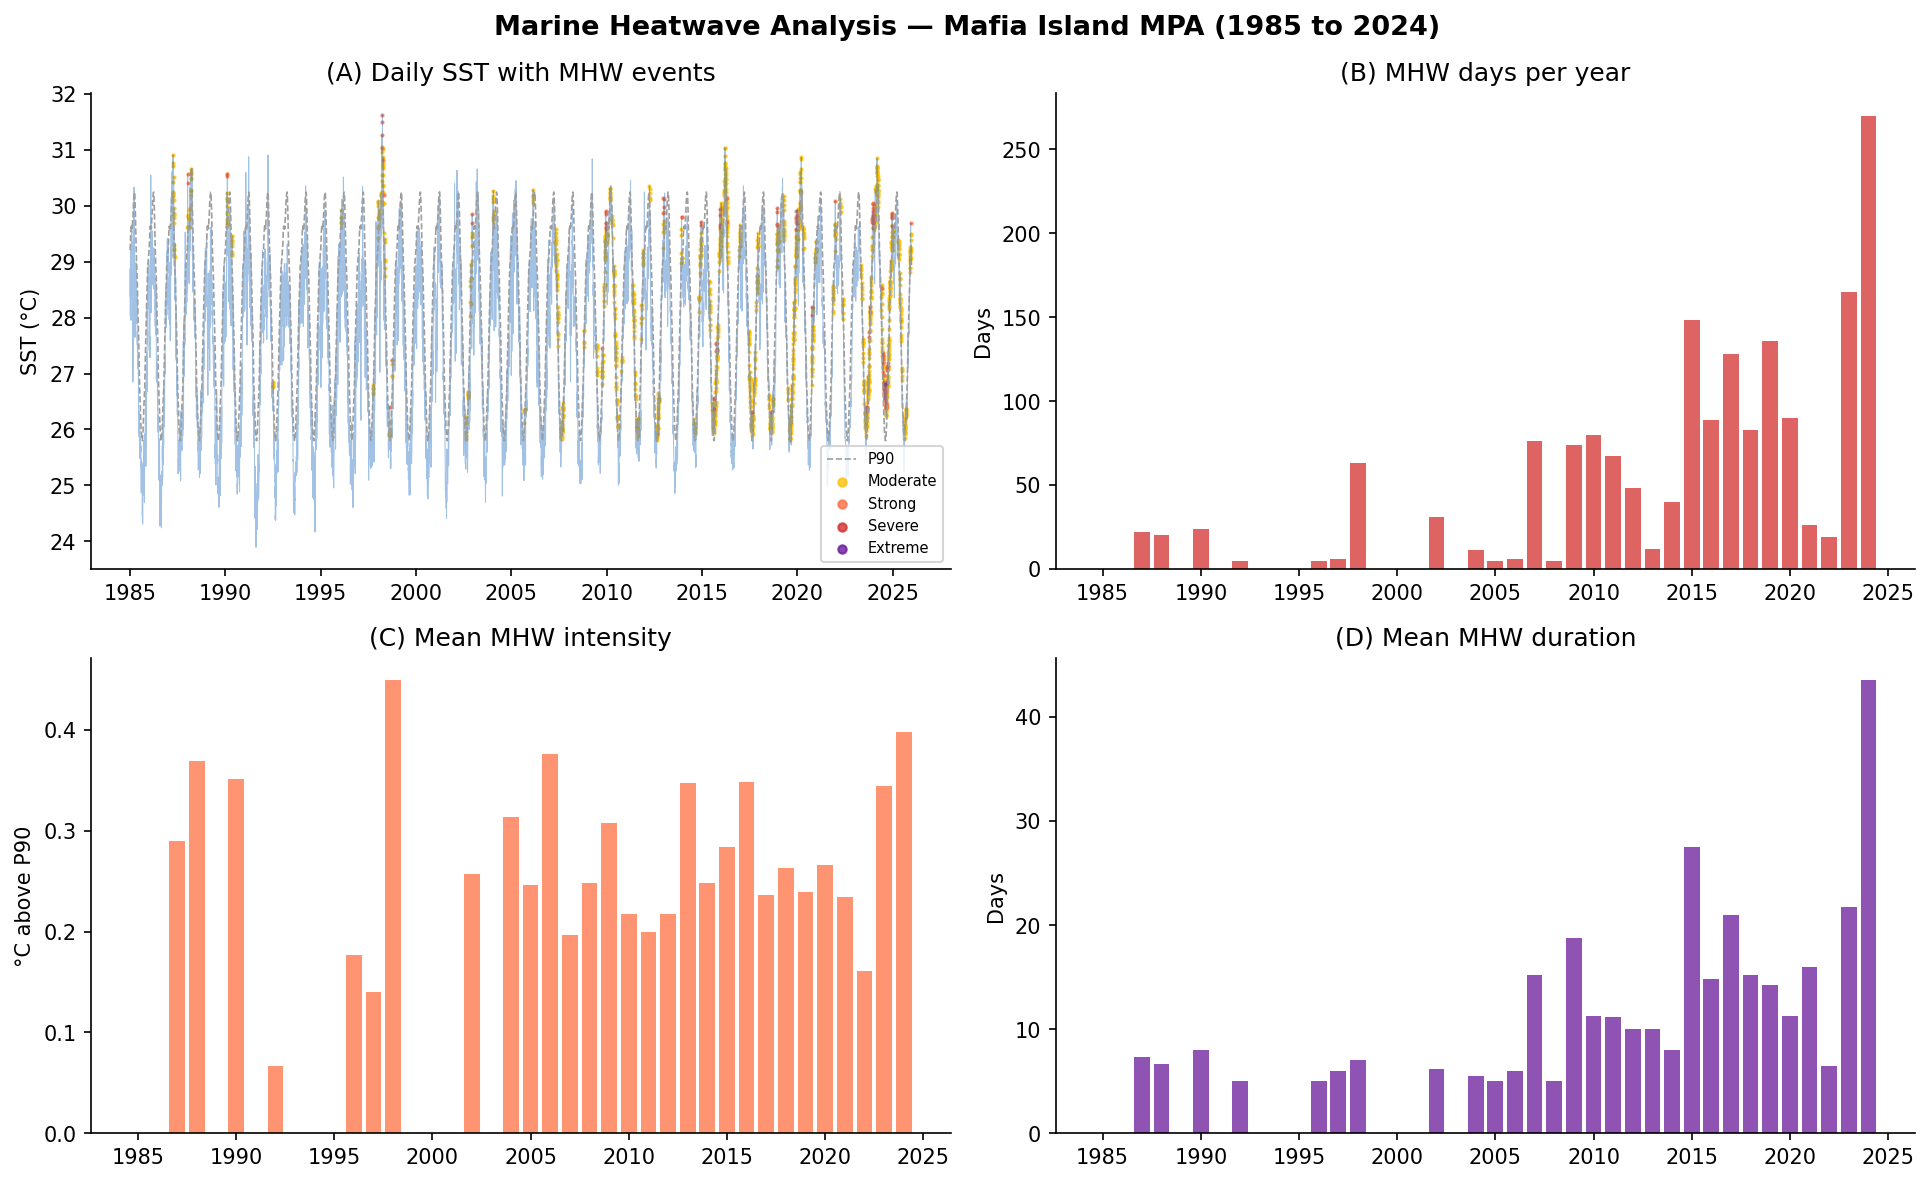

Saved to E:\Git_Repositories\CliMPA\indicators\01_SST\figures\fig3_MHW_analysis.png


In [104]:
daily_mhw = pd.read_csv(DATA_PROC / "MHW_daily_flags.csv", parse_dates=["date"])
mhw_ev    = pd.read_csv(DATA_PROC / "MHW_events.csv")

annual_mhw = (
    daily_mhw[daily_mhw["mhw_event"]]
    .groupby("year").agg(mhw_days=("mhw_event", "sum"), mean_intensity=("intensity", "mean"))
    .reset_index()
)
all_years  = pd.DataFrame({"year": range(RECORD_START, RECORD_END + 1)})
annual_mhw = all_years.merge(annual_mhw, on="year", how="left").fillna(0)

if len(mhw_ev):
    mhw_ev["year"] = pd.to_datetime(mhw_ev["start"]).dt.year
    dur_yr         = mhw_ev.groupby("year")["duration_days"].mean().rename("mean_duration")
    annual_mhw     = annual_mhw.merge(dur_yr, on="year", how="left").fillna(0)
else:
    annual_mhw["mean_duration"] = 0

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Marine Heatwave Analysis — Mafia Island MPA (1985 to 2024)",
             fontsize=13, fontweight="bold")

ax = axes[0, 0]
ax.plot(daily_mhw["date"], daily_mhw["sst"], color=C_SST, lw=0.5, alpha=0.4)
ax.plot(daily_mhw["date"], daily_mhw["p90"], color="#9E9E9E", lw=0.8, ls="--", label="P90")
for cat, col in MHW_COLOURS.items():
    mask = daily_mhw["category"] == cat
    ax.scatter(daily_mhw.loc[mask, "date"], daily_mhw.loc[mask, "sst"],
               color=col, s=1, alpha=0.8, label=cat)
ax.set_title("(A) Daily SST with MHW events")
ax.set_ylabel("SST (°C)")
ax.legend(fontsize=7, markerscale=4)

axes[0, 1].bar(annual_mhw["year"], annual_mhw["mhw_days"],      color=C_SMOOTH, alpha=0.75)
axes[0, 1].set_title("(B) MHW days per year")
axes[0, 1].set_ylabel("Days")

axes[1, 0].bar(annual_mhw["year"], annual_mhw["mean_intensity"], color="#FF7043", alpha=0.75)
axes[1, 0].set_title("(C) Mean MHW intensity")
axes[1, 0].set_ylabel("°C above P90")

axes[1, 1].bar(annual_mhw["year"], annual_mhw["mean_duration"],  color="#6A1B9A", alpha=0.75)
axes[1, 1].set_title("(D) Mean MHW duration")
axes[1, 1].set_ylabel("Days")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_MHW_analysis.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig3_MHW_analysis.svg", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG_DIR / 'fig3_MHW_analysis.png'}")


## 8. Figure 4 — Degree heating weeks (CRW)

Source: NOAA Coral Reef Watch Virtual Station Tanzania
URL: https://coralreefwatch.noaa.gov/product/vs/data/tanzania.txt

To save the file, open the URL above in your browser, select all (Ctrl+A), copy (Ctrl+C), paste into Notepad and save as CRW_DHW_Tanzania.txt into data/raw/. The file contains a metadata header of approximately 15 lines before the data columns. The load cell below detects this automatically by scanning for the line that begins with YYYY.


In [105]:
crw_file = DATA_RAW / "CRW_DHW_Tanzania.txt"

with open(crw_file, "r") as f:
    lines = f.readlines()

skip = next(i for i, l in enumerate(lines) if l.strip().startswith("YYYY"))
print(f"Header rows skipped: {skip} | Data starts at line {skip + 1}")

col_names = [
    "Year", "Month", "Day",
    "SST_MIN", "SST_MAX",
    "SSTat90th_HS", "SSTAat90th_HS",
    "HS90_gt0", "DHW", "BAA"
]

crw = pd.read_csv(crw_file, sep=r"\s+", skiprows=skip + 1,
                  header=None, names=col_names)

crw["Date"] = pd.to_datetime(crw[["Year", "Month", "Day"]])
crw = crw.set_index("Date").sort_index()

print(f"CRW record: {crw.index.min().date()} to {crw.index.max().date()}")
print(f"Rows: {len(crw):,}")
print(crw.head())


Header rows skipped: 21 | Data starts at line 22
CRW record: 1985-01-01 to 2026-05-28
Rows: 15,098
            Year  Month  Day  SST_MIN  SST_MAX  SSTat90th_HS  SSTAat90th_HS  \
Date                                                                          
1985-01-01  1985      1    1    27.99    28.23         28.19        -0.0606   
1985-01-02  1985      1    2    27.89    28.24         28.15        -0.0158   
1985-01-03  1985      1    3    27.90    28.33         28.16        -0.0277   
1985-01-04  1985      1    4    27.75    28.36         28.20         0.0629   
1985-01-05  1985      1    5    27.30    28.26         27.95        -0.1694   

            HS90_gt0  DHW  BAA  
Date                            
1985-01-01       0.0  0.0    0  
1985-01-02       0.0  0.0    0  
1985-01-03       0.0  0.0    0  
1985-01-04       0.0  0.0    0  
1985-01-05       0.0  0.0    0  


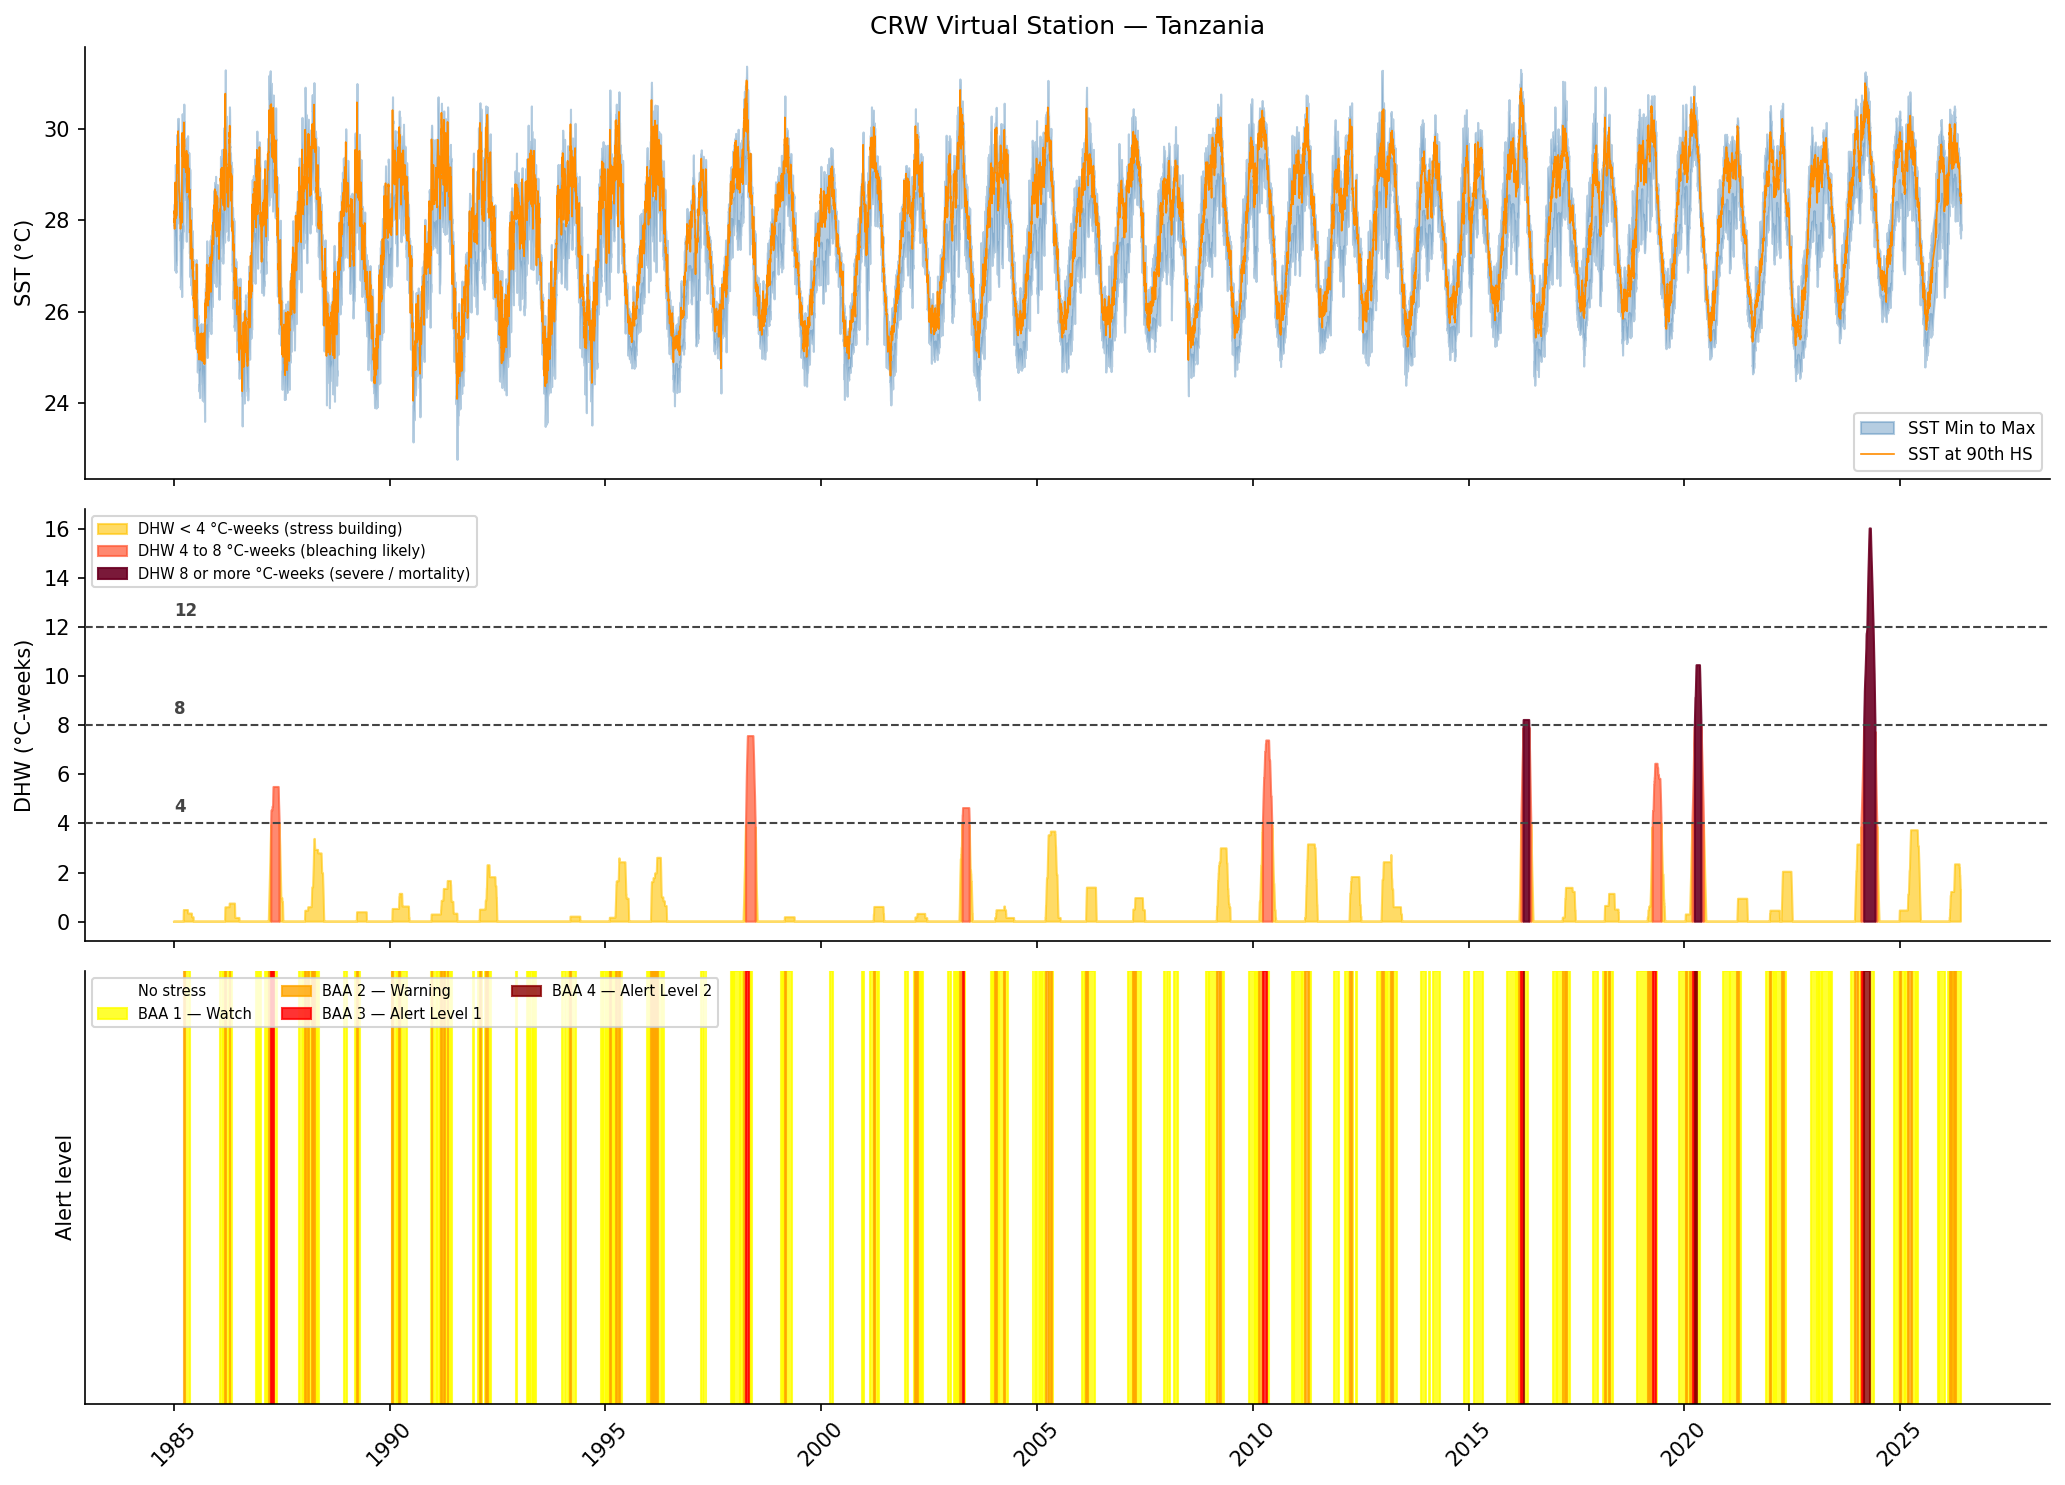

Saved to E:\Git_Repositories\CliMPA\indicators\01_SST\figures\fig4_CRW_DHW_Tanzania.png


In [85]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 — SST range
axes[0].fill_between(crw.index, crw["SST_MIN"], crw["SST_MAX"],
                     alpha=0.4, color="steelblue", label="SST Min to Max")
axes[0].plot(crw.index, crw["SSTat90th_HS"], color="darkorange",
             linewidth=0.8, label="SST at 90th HS")
axes[0].set_ylabel("SST (°C)")
axes[0].set_title("CRW Virtual Station — Tanzania")
axes[0].legend(fontsize=8)

# Panel 2 — DHW as continuous thermal stress magnitude
# Both 4 and 8 DHW can cause bleaching; colour reflects magnitude not category
axes[1].fill_between(crw.index, 0, crw["DHW"],
                     where=crw["DHW"] < 4,
                     color="#FFC300", alpha=0.6, label="DHW < 4 °C-weeks (stress building)")
axes[1].fill_between(crw.index, 0, crw["DHW"],
                     where=(crw["DHW"] >= 4) & (crw["DHW"] < 8),
                     color="#FF5733", alpha=0.7, label="DHW 4 to 8 °C-weeks (bleaching likely)")
axes[1].fill_between(crw.index, 0, crw["DHW"],
                     where=crw["DHW"] >= 8,
                     color="#6C0023", alpha=0.9, label="DHW 8 or more °C-weeks (severe / mortality)")

for dhw_val, lbl in [(4, "4"), (8, "8"), (12, "12")]:
    axes[1].axhline(dhw_val, color="#444", linestyle="--", linewidth=1.0, zorder=3)
    axes[1].text(crw.index[0], dhw_val + 0.3, lbl,
                 fontsize=8, color="#444", va="bottom", ha="left", fontweight="bold")

axes[1].set_ylabel("DHW (°C-weeks)")
axes[1].legend(fontsize=7, loc="upper left")

# Panel 3 — Bleaching Alert Area
baa_colors = {
    0: ("white",   "No stress"),
    1: ("yellow",  "BAA 1 — Watch"),
    2: ("orange",  "BAA 2 — Warning"),
    3: ("red",     "BAA 3 — Alert Level 1"),
    4: ("darkred", "BAA 4 — Alert Level 2"),
}
for level, (color, label) in baa_colors.items():
    mask = crw["BAA"] == level
    axes[2].fill_between(crw.index, 0, 1,
                         where=mask, transform=axes[2].get_xaxis_transform(),
                         color=color, alpha=0.8, label=label)
axes[2].set_ylabel("Alert level")
axes[2].set_yticks([])
axes[2].legend(fontsize=7, ncol=3, loc="upper left")

axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_CRW_DHW_Tanzania.png", dpi=150, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig4_CRW_DHW_Tanzania.svg", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG_DIR / 'fig4_CRW_DHW_Tanzania.png'}")


## 9. Figure 5 — SST anomaly heatmap

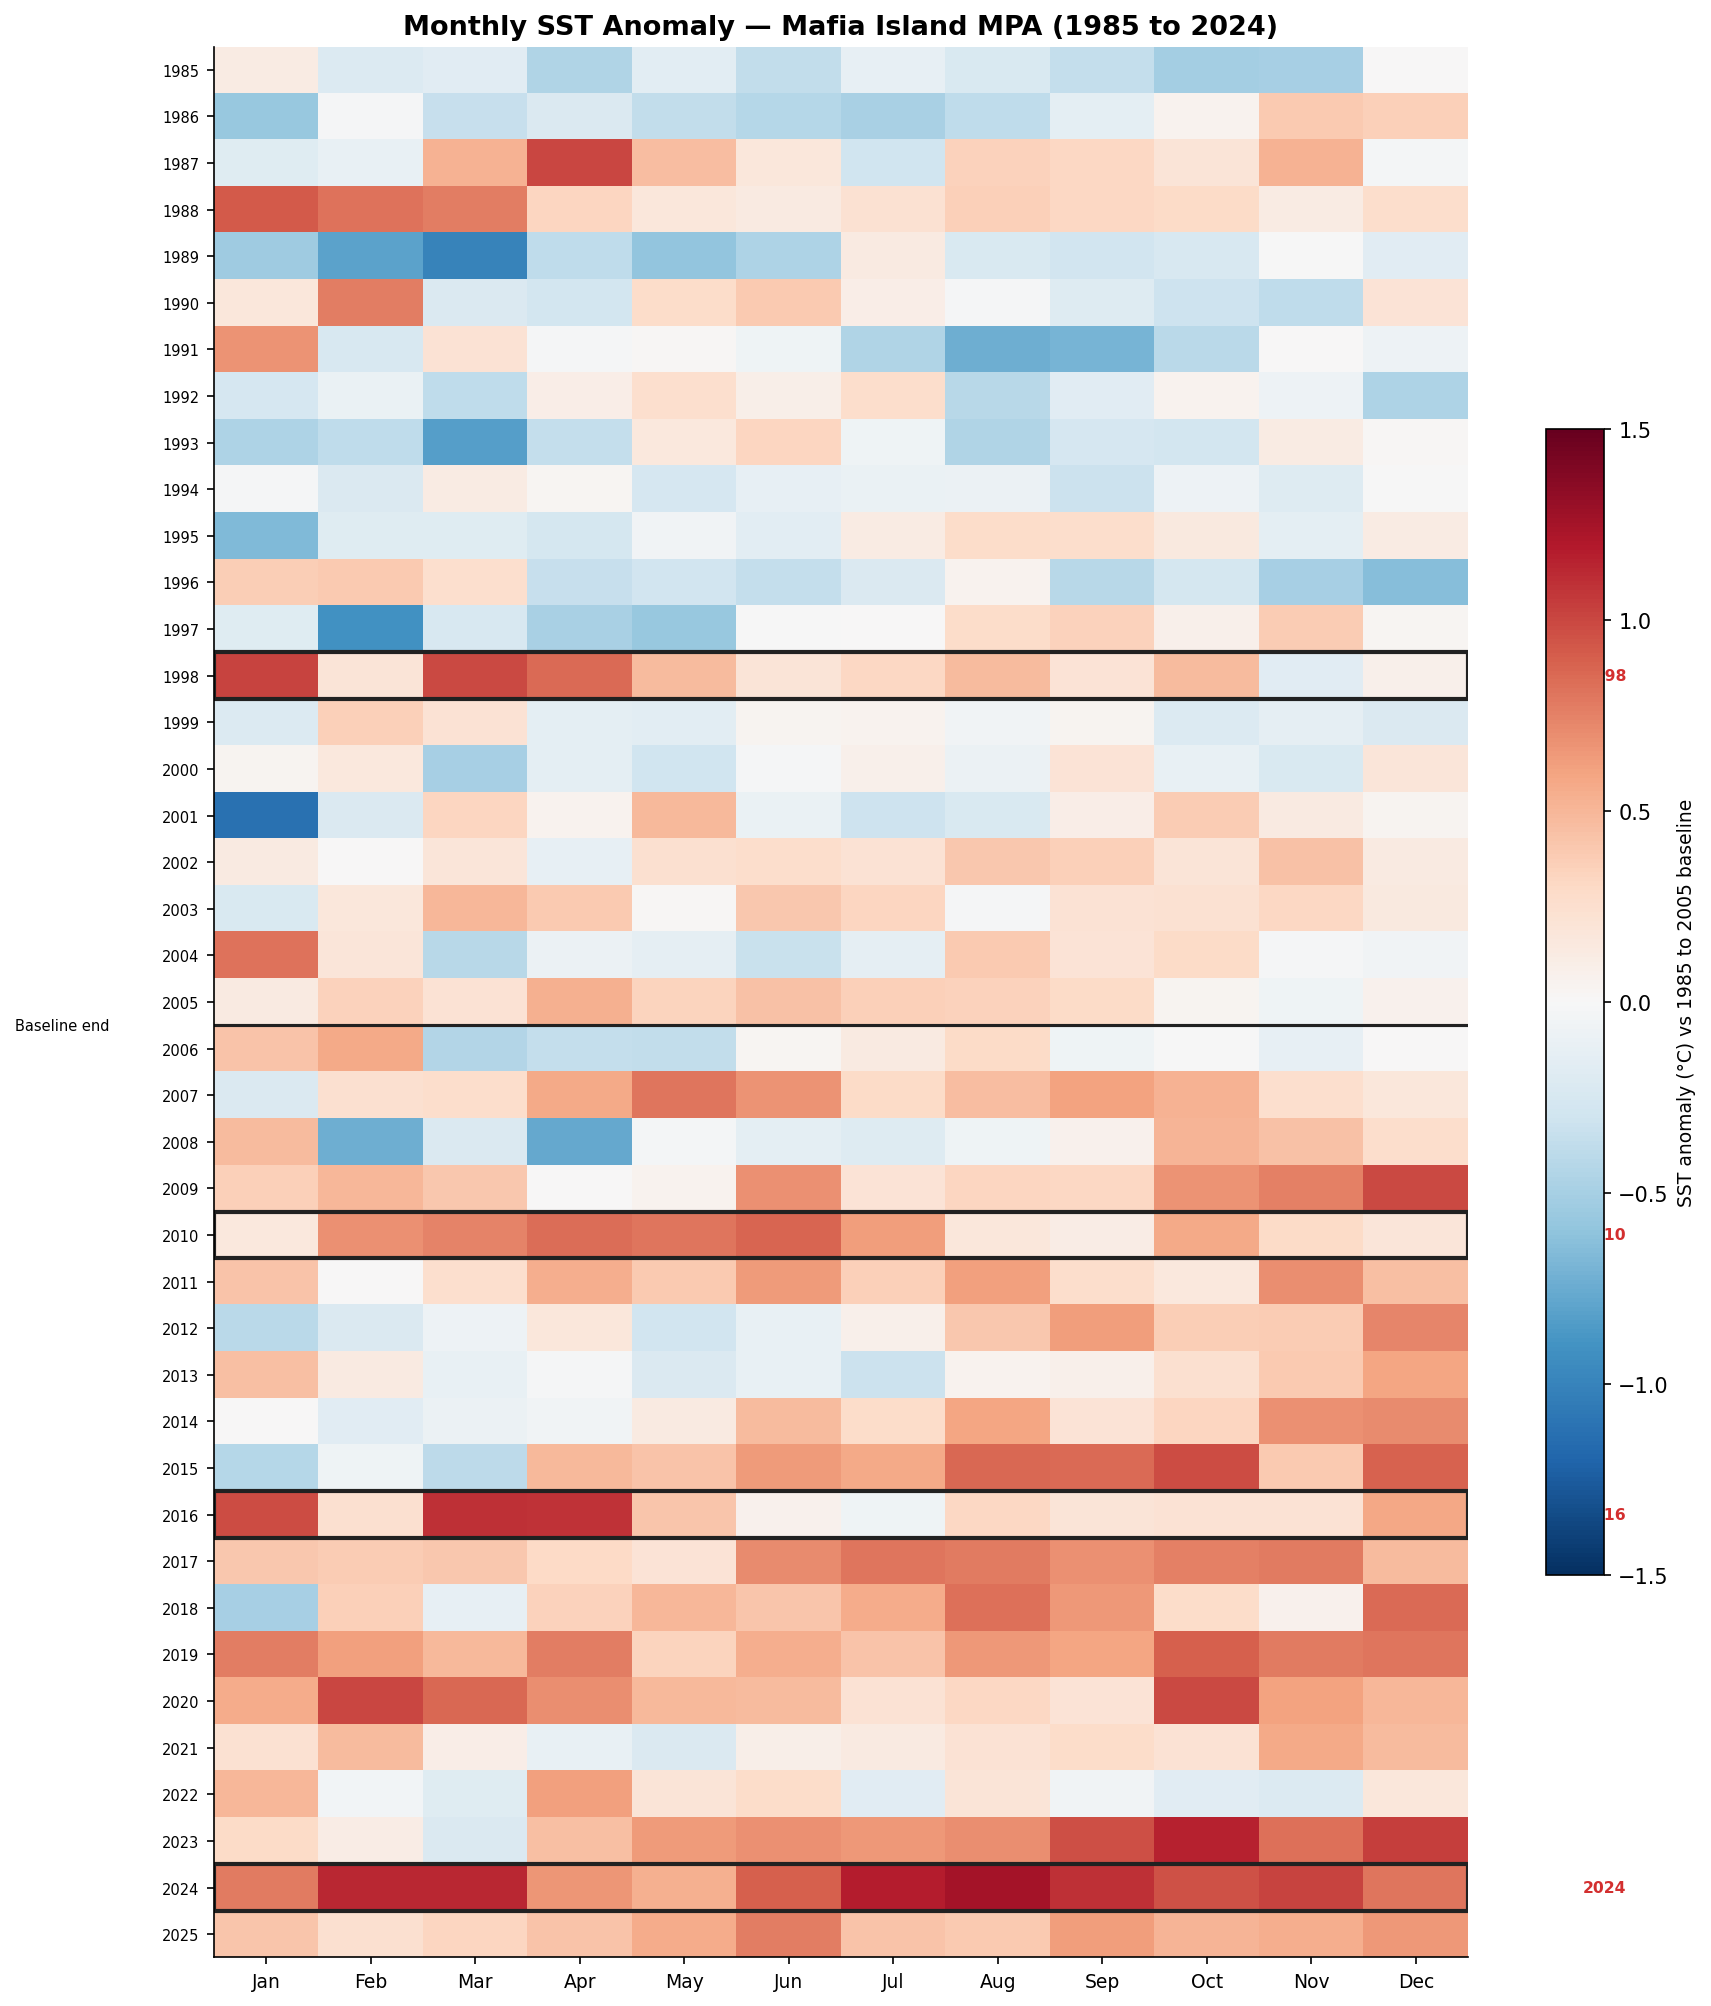

Saved to E:\Git_Repositories\CliMPA\indicators\01_SST\figures\fig5_SST_anomaly_heatmap.png


In [106]:
anomaly = pd.read_csv(DATA_PROC / "SST_anomaly_monthly.csv")
grid    = anomaly.pivot(index="year", columns="month", values="anomaly").sort_index()
years   = grid.index.values
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, len(years) * 0.28 + 2))
norm_hm = mcolors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.5)
im      = ax.imshow(grid.values, aspect="auto", cmap="RdBu_r",
                    norm=norm_hm, interpolation="nearest")

bl_idx = np.where(years == BASELINE_END)[0]
if len(bl_idx):
    ax.axhline(bl_idx[0] + 0.5, color="#212121", lw=1.5)
    ax.text(-1.5, bl_idx[0] + 0.5, "Baseline end", fontsize=7, ha="right", va="center")

for yr in BLEACHING_YEARS:
    idx = np.where(years == yr)[0]
    if len(idx):
        ax.add_patch(plt.Rectangle((-0.5, idx[0] - 0.5), 12, 1,
                     lw=2, edgecolor="#212121", facecolor="none"))
        ax.text(12.6, idx[0], str(yr), fontsize=7.5, va="center",
                color="#D32F2F", fontweight="bold")

ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_LABELS, fontsize=9)
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years, fontsize=7)
ax.set_title("Monthly SST Anomaly — Mafia Island MPA (1985 to 2024)",
             fontsize=13, fontweight="bold")
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label("SST anomaly (°C) vs 1985 to 2005 baseline", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_SST_anomaly_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig5_SST_anomaly_heatmap.svg", bbox_inches="tight")
plt.show()
print(f"Saved to {FIG_DIR / 'fig5_SST_anomaly_heatmap.png'}")


## 10. Export headline numbers and visual summary

In [107]:
monthly = pd.read_csv(DATA_PROC / "SST_monthly.csv")
mhw_ev  = pd.read_csv(DATA_PROC / "MHW_events.csv")

mhw_ev["start"] = pd.to_datetime(mhw_ev["start"])
mhw_ev["end"]   = pd.to_datetime(mhw_ev["end"])

early_cool  = monthly[(monthly["year"].between(1985, 2000)) & monthly["month"].isin([6,7,8,9])]["sst_mean"].mean()
recent_cool = monthly[(monthly["year"].between(2005, 2024)) & monthly["month"].isin([6,7,8,9])]["sst_mean"].mean()

cat_counts = mhw_ev["max_category"].value_counts().to_dict()

headline = {
    "indicator":                    "01_SST",
    "warming_rate_C_per_decade":    round(float(rate), 3),
    "trend_r_squared":              round(float(r**2), 3),
    "trend_p_value":                round(float(p), 4),
    "trend_significant":            bool(p < 0.05),
    "mean_sst_baseline_1985_2005":  round(float(monthly[monthly["year"].between(1985, 2005)]["sst_mean"].mean()), 2),
    "mean_sst_recent_2010_2024":    round(float(monthly[monthly["year"].between(2010, 2024)]["sst_mean"].mean()), 2),
    "cool_season_shift_C":          round(float(recent_cool - early_cool), 2),
    "mhw_total_events":             int(len(mhw_ev)),
    "mhw_moderate_events":          int(cat_counts.get("Moderate", 0)),
    "mhw_strong_events":            int(cat_counts.get("Strong", 0)),
    "mhw_severe_events":            int(cat_counts.get("Severe", 0)),
    "mhw_extreme_events":           int(cat_counts.get("Extreme", 0)),
    "mhw_longest_event_days":       int(mhw_ev["duration_days"].max()),
    "mhw_most_intense_C_above_p90": round(float(mhw_ev["max_intensity"].max()), 2),
}

out = DATA_OUT / "SST_headline_numbers.json"
with open(out, "w") as f:
    json.dump(headline, f, indent=2)

print("── SST HEADLINE NUMBERS ──────────────────────────────────────")
for k, v in headline.items():
    print(f"  {k:<45s} {v}")
print(f"\nSaved to {out}")


── SST HEADLINE NUMBERS ──────────────────────────────────────
  indicator                                     01_SST
  warming_rate_C_per_decade                     0.165
  trend_r_squared                               0.02
  trend_p_value                                 0.0018
  trend_significant                             True
  mean_sst_baseline_1985_2005                   27.46
  mean_sst_recent_2010_2024                     27.88
  cool_season_shift_C                           0.44
  mhw_total_events                              129
  mhw_moderate_events                           128
  mhw_strong_events                             1
  mhw_severe_events                             0
  mhw_extreme_events                            0
  mhw_longest_event_days                        124
  mhw_most_intense_C_above_p90                  1.4

Saved to E:\Git_Repositories\CliMPA\indicators\01_SST\data\outputs\SST_headline_numbers.json


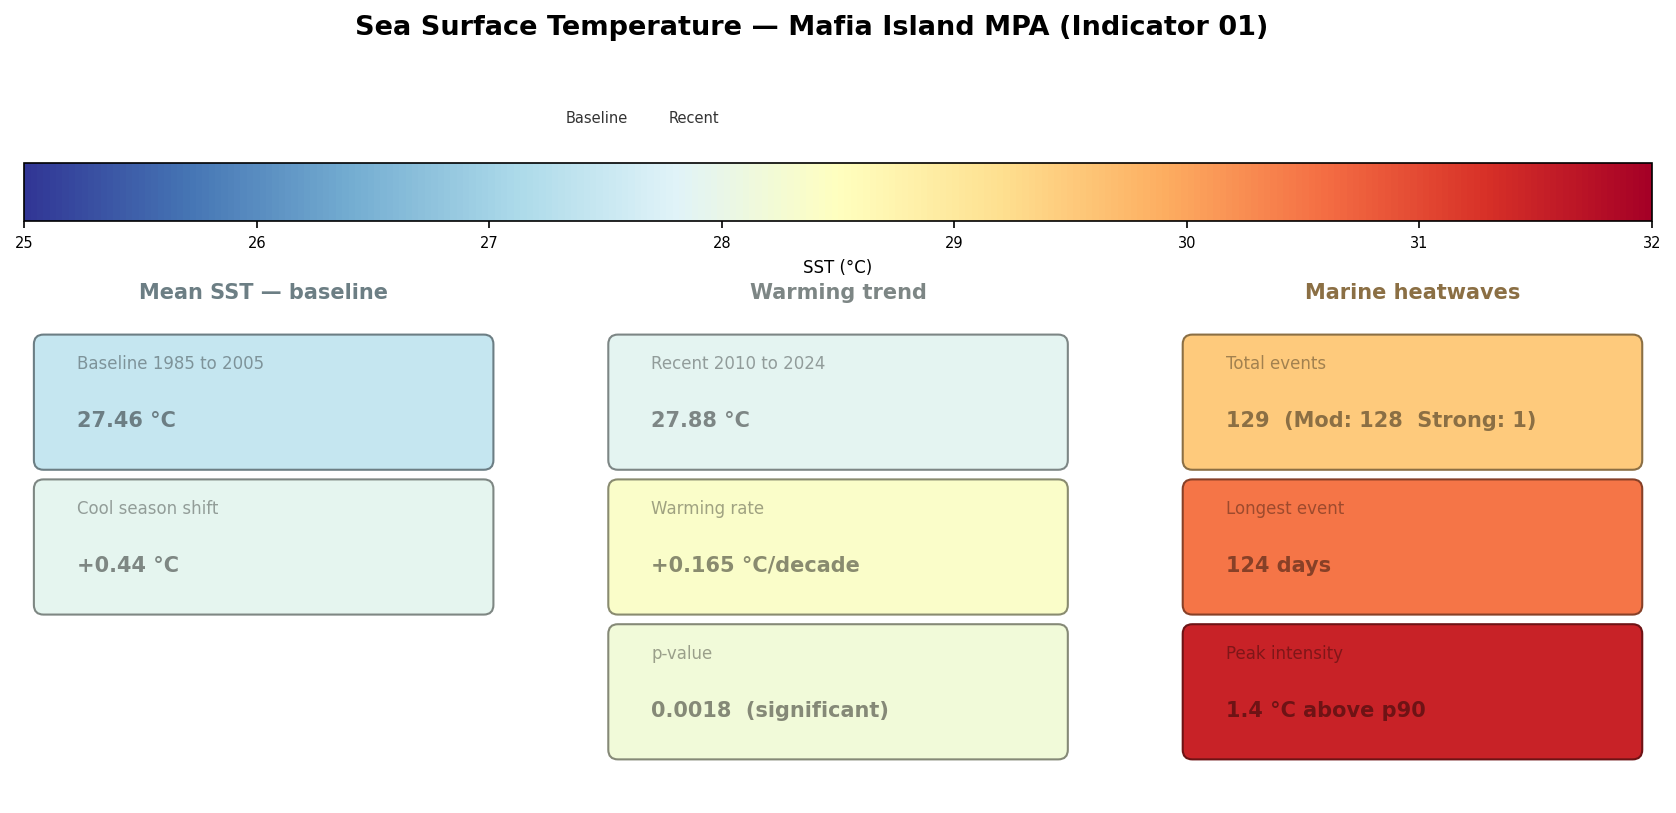

Saved to E:\Git_Repositories\CliMPA\indicators\01_SST\figures\SST_headline_visual.png


In [108]:
# Headline visual — thermal colour cards
cmap_cards = plt.get_cmap("RdYlBu_r")
norm_cards = mcolors.Normalize(vmin=25.0, vmax=32.0)

def card_colors(sst_val):
    rgba = cmap_cards(norm_cards(sst_val))
    face = mcolors.to_hex(rgba)
    dark = mcolors.to_hex([max(0, c * 0.55) for c in rgba[:3]])
    return face, dark, dark

sections = [
    ("Mean SST — baseline", [
        ("Baseline 1985 to 2005", f"{headline['mean_sst_baseline_1985_2005']} °C",
                                   headline["mean_sst_baseline_1985_2005"]),
        ("Cool season shift",     f"+{headline['cool_season_shift_C']} °C",
                                   headline["mean_sst_baseline_1985_2005"] + headline["cool_season_shift_C"]),
    ]),
    ("Warming trend", [
        ("Recent 2010 to 2024",   f"{headline['mean_sst_recent_2010_2024']} °C",
                                   headline["mean_sst_recent_2010_2024"]),
        ("Warming rate",          f"+{headline['warming_rate_C_per_decade']} °C/decade",
                                   headline["mean_sst_recent_2010_2024"] + 0.5),
        ("p-value",               f"{headline['trend_p_value']}  (significant)",
                                   headline["mean_sst_recent_2010_2024"] + 0.3),
    ]),
    ("Marine heatwaves", [
        ("Total events",          f"{headline['mhw_total_events']}  (Mod: {headline['mhw_moderate_events']}  Strong: {headline['mhw_strong_events']})",
                                   29.5),
        ("Longest event",         f"{headline['mhw_longest_event_days']} days",
                                   30.5),
        ("Peak intensity",        f"{headline['mhw_most_intense_C_above_p90']} °C above p90",
                                   31.5),
    ]),
]

fig = plt.figure(figsize=(14, 5.5))
gs  = fig.add_gridspec(2, 3, height_ratios=[0.12, 1], hspace=0.35)

ax_bar = fig.add_subplot(gs[0, :])
cb = plt.colorbar(
    plt.cm.ScalarMappable(cmap=cmap_cards, norm=norm_cards),
    cax=ax_bar, orientation="horizontal")
cb.set_label("SST (°C)", fontsize=8)
cb.ax.tick_params(labelsize=7)

for val, label in [
    (headline["mean_sst_baseline_1985_2005"], "Baseline"),
    (headline["mean_sst_recent_2010_2024"],   "Recent"),
]:
    norm_x = norm_cards(val)
    ax_bar.axvline(norm_x, color="white", linewidth=1.5)
    ax_bar.text(norm_x, 1.7, label, fontsize=7, color="#333",
                ha="center", transform=ax_bar.transAxes)

fig.suptitle("Sea Surface Temperature — Mafia Island MPA (Indicator 01)",
             fontsize=13, fontweight="bold", y=1.06)

for col, (title, cards) in enumerate(sections):
    ax = fig.add_subplot(gs[1, col])
    ax.axis("off")
    _, _, title_txt = card_colors(cards[0][2])
    ax.set_title(title, fontsize=10, fontweight="bold", color=title_txt, pad=8)
    for i, (label, value, sst_val) in enumerate(cards):
        bg, border, txt = card_colors(sst_val)
        y = 0.82 - i * 0.30
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.04, y - 0.12), 0.92, 0.24,
            boxstyle="round,pad=0.02",
            facecolor=bg, edgecolor=border, linewidth=1,
            transform=ax.transAxes, clip_on=False))
        ax.text(0.11, y + 0.07, label,
                fontsize=8, color=txt, alpha=0.8, transform=ax.transAxes)
        ax.text(0.11, y - 0.05, value,
                fontsize=10, fontweight="bold", color=txt,
                transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIG_DIR / "SST_headline_visual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {FIG_DIR / 'SST_headline_visual.png'}")
